# Wizualizacja danych w Pythonie
## Matplotlib & Seaborn — od podstaw

**Dane:** Pingwiny Palmer  
**Biblioteki:** `matplotlib`, `seaborn`, `pandas`, `numpy`


---
## 0. Import bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Matplotlib od podstaw


Matplotlib rysuje na dwóch obiektach:
- **Figure** — cała "kartka papieru"
- **Axes** — jeden wykres (osie, dane, tytuł)

Minimalna recepta:
```python
plt.figure()          # nowa kartka
plt.plot(x, y)        # narysuj dane
plt.show()            # wyświetl
```

### 1.1 Jak narysować prostą

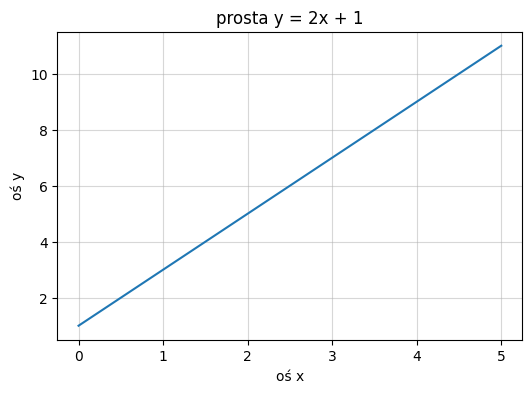

In [2]:
# prosta y = 2x + 1
x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))        # rozmiar figury w calach (szerokość, wysokość)
plt.plot(x, y)                    # rysuje linię łączącą punkty po kolei
plt.xlabel('oś x')
plt.ylabel('oś y')
plt.title('prosta y = 2x + 1')
plt.grid(True, alpha=0.5)         # siatka pomocnicza, alpha = przezroczystość, true to grid się pojawia
plt.show()

### 1.2 Jak postawić punkt (scatter)

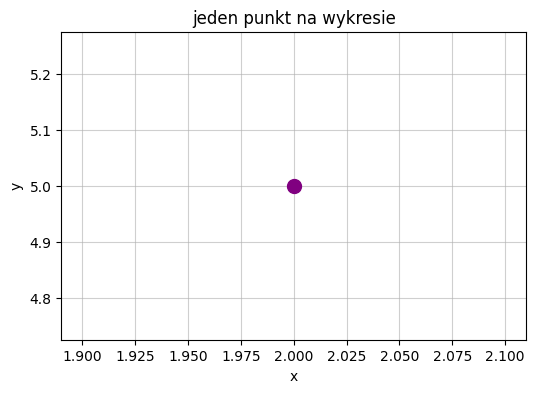

In [3]:
# plt.scatter rysuje pojedyncze punkty, nie łączy ich linią
x_punkt = [2]
y_punkt = [5]

plt.figure(figsize=(6, 4))
plt.scatter(x_punkt, y_punkt,
            color='purple',    # kolor punktu
            s=100,          # rozmiar punktu (domyślnie 36)) 
            zorder = 2)     # zorder decyduje co jest "na wierzchu"
plt.xlabel('x')
plt.ylabel('y')
plt.title('jeden punkt na wykresie')
plt.grid(True, alpha=0.6)
plt.show()

### 1.3 Punkty połączone prostą

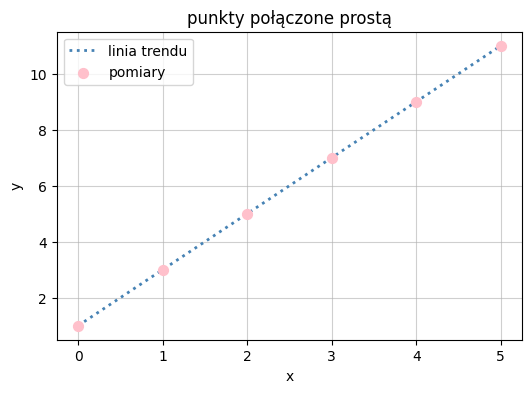

In [4]:
# plt.plot i plt.scatter można łączyć na jednym wykresie
# dwa wywołania przed plt.show() rysują na tej samej figurze

x = [0, 1, 2, 3, 4, 5]
y = [1, 3, 5, 7, 9, 11]

plt.figure(figsize=(6, 4))

# linia
plt.plot(x, y,
         color='steelblue',
         linewidth=2,
         linestyle=':',    # '--' przerywana, '-' ciągła, ':' kropkowana
         label='linia trendu')

# punkty na tej samej figurze
plt.scatter(x, y,
            color='pink',
            s=50,
            zorder=5,
            label='pomiary')

plt.xlabel('x')
plt.ylabel('y')
plt.title('punkty połączone prostą')
plt.legend()               # legenda — bierze etykiety z label=
plt.grid(True, alpha=0.6)
plt.show()

### Zadanie 1

Narysuj na jednym wykresie dwie proste:
- `y1 = x` (kolor zielony, linia ciągła)
- `y2 = x**2` (kolor pomarańczowy, linia przerywana `'--'`)

Zakres x: `[0, 1, 2, 3, 4]`  
Dodaj tytuł, etykiety osi i legendę.

> 💡 Dwa razy `plt.plot(...)` przed `plt.show()` rysuje obie linie na jednym wykresie.

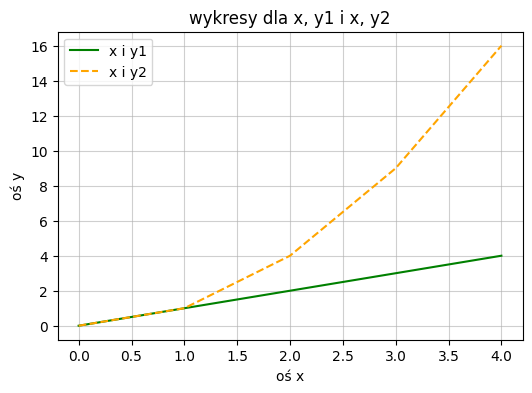

In [5]:
x = [0, 1, 2, 3, 4]
y1 = x
#UWAGA wyrażeie listowe  →łądnie skraca kod
y2 = [x1**2 for x1 in x]

plt.figure(figsize=(6, 4))

plt.plot(x, y1,
         color="green",
         linestyle="-",
         label="x i y1",
        )

plt.plot(x, y2,
         color="orange",
         linestyle="--",
         label="x i y2",
        )


plt.xlabel('oś x')
plt.ylabel('oś y')
plt.title('wykresy dla x, y1 i x, y2')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()


---
## 2. Wgrywanie danych i eksploracja


### 2.1 Wczytanie danych

In [6]:
# zbiór Palmer Penguins — wbudowany w Seaborn, nie trzeba nic pobierać
pewpew = sns.load_dataset('penguins')

# jak wyświetlić pierwsze 7 wierszy?
pewpew.head(7)
#wystepuja braki :()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female


### 2.2 Podstawowe informacje o zbiorze

In [7]:
# wyświetlamy wymiar danych: (wiersze, kolumny)
print('wymiar:', pewpew.shape)
print()

# wyświetlamy typy kolumn i liczba braków
print('typy kolumn i braki:')
print(pewpew.info())

wymiar: (344, 7)

typy kolumn i braki:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
None


In [8]:
# czy są braki w danych?
print('liczba braków w każdej kolumnie:')
print(pewpew.isna().sum())
print()
print(f'wierszy z co najmniej jednym brakiem: {pewpew.isnull().any(axis=1).sum()}')

liczba braków w każdej kolumnie:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

wierszy z co najmniej jednym brakiem: 11


In [9]:
# podstawowe statystyki opisowe dla kolumn liczbowych
pewpew.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


In [10]:
# Ile pingwinów każdego gatunku?
print('Liczba pingwinów wg gatunku:')
# kolumna species
print(pewpew["species"].value_counts())
print()
# kolumna island
print('Liczba pingwinów wg wyspy:')
print(pewpew["island"].value_counts())

Liczba pingwinów wg gatunku:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Liczba pingwinów wg wyspy:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [11]:
# usuwamy wiersze z brakami — reszta zajęć na czystych danych
ping = pewpew.dropna().reset_index(drop=True)
print(f'Wierszy po usunięciu braków: {len(ping)}')

# słownik kolorów — używamy go przez cały notatnik dla spójności
KOLORY = {'Adelie': "#D6B583", 'Gentoo': "#6FC4B7", 'Chinstrap': "#BC86DB"}

Wierszy po usunięciu braków: 333


###  Zadanie 2

1. Ile jest unikalnych wartości w kolumnie `island`? 
2. Jaka jest średnia masa ciała (`body_mass_g`) dla każdego gatunku?  
3. Ile pingwinów to samce, ile samice? 

In [12]:
# 1. Unikalne wyspy
w = ping["island"].nunique()
# 2. Średnia masa wg gatunku
m = ping.groupby("species")["body_mass_g"].mean()
# 3. Podział na płeć
s = ping["sex"].value_counts()

print(f'''{w},
{m}
{s}''')

3,
species
Adelie       3706.164384
Chinstrap    3733.088235
Gentoo       5092.436975
Name: body_mass_g, dtype: float64
sex
Male      168
Female    165
Name: count, dtype: int64


---
## 3. Pie chart — rozkład klas


Pie chart przydaje się gdy chcemy pokazać **udziały procentowe** kategorii.  
Używamy go gdy mamy 2–5 kategorii — przy większej liczbie trudno odczytać wartości.

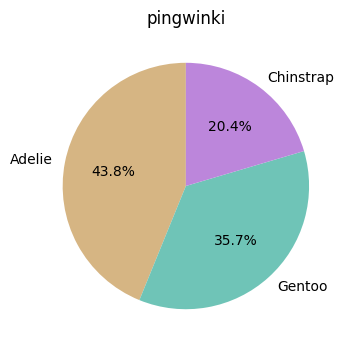

In [13]:
# zliczamy pingwiny wg gatunku
species = ping["species"].value_counts()

#na piechart umieszcza sie od 3-5 czesci bo inaczej jest nieczytelny
plt.figure(figsize=(6, 4))
plt.pie(
    species.values,
    labels=species.index,
    colors=list(KOLORY.values()),
    autopct="%1.1f%%", #wyświetlanie procentow jako tekst w etykietach, a % to znak specjalny
    startangle=90
    )  
plt.title("pingwinki", fontsize=12)
plt.show()

###  Zadanie 3

Narysuj pie chart pokazujący **rozkład wysp** (kolumna `island`), nie gatunków.  
Użyj dowolnych kolorów. Dodaj tytuł.

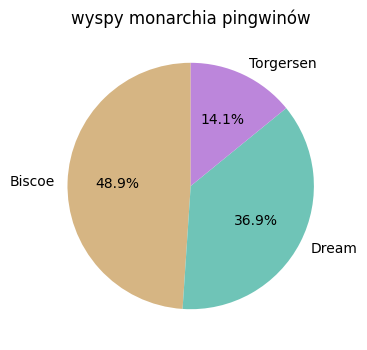

In [14]:
isln = ping["island"].value_counts()

plt.figure(figsize=(6, 4))
plt.pie(
    isln.values,
    labels=isln.index,
    colors=list(KOLORY.values()),
    autopct="%1.1f%%",
    startangle=90
    )  
plt.title("wyspy monarchia pingwinów", fontsize=12)
plt.show()

---
## 4. Histogram — rozkład jednej zmiennej


Histogram dzieli zakres wartości na przedziały (`bins`) i liczy ile obserwacji wpada do każdego.  
Używamy go do sprawdzenia **kształtu rozkładu** — czy jest normalny, skośny, wielomodalny.

### 4.1 Podstawowy histogram

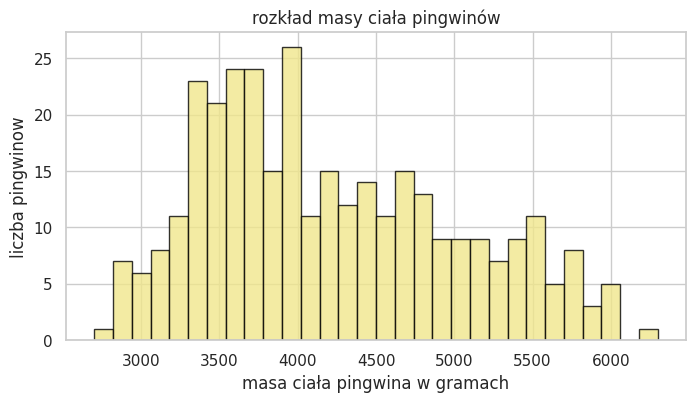

In [33]:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["body_mass_g"],
    bins=30,
    color="khaki",
    #dla czytelnosci nizej
    edgecolor="black",
    alpha=0.8
    )

plt.xlabel("masa ciała pingwina w gramach")
plt.ylabel("liczba pingwinow")
plt.title("rozkład masy ciała pingwinów")

plt.show()

### 4.2 axvline — linie dla mediany i średniej

Kiedy chcemy zaznaczyć na histogramie konkretną wartość (próg, statystykę) — używamy `plt.axvline()`.

In [16]:
srednia = ping["body_mass_g"].mean()
mediana = ping["body_mass_g"].median()
print(f'Srednia: {srednia:.0f} g')
print(f'Mediana: {mediana:.0f} g')

Srednia: 4207 g
Mediana: 4050 g


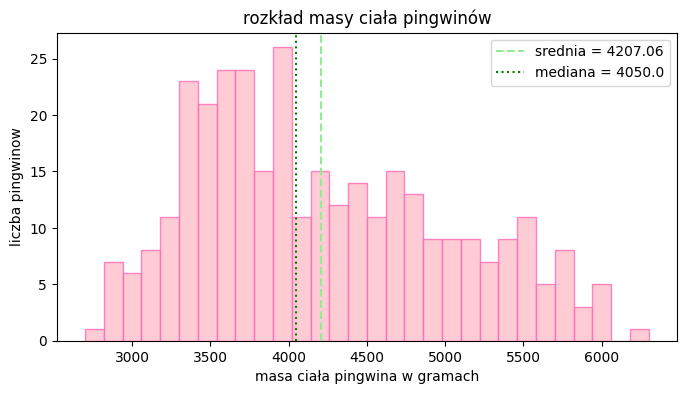

In [17]:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["body_mass_g"],
    bins=30,
    color="pink",
    #dla czytelnosci nizej
    edgecolor="hotpink",
    alpha=0.8
    )

plt.axvline(x = srednia, color="lightgreen", linestyle="--", label=f"srednia = {srednia.round(2)}")
plt.axvline(x = mediana, color="green", linestyle=":", label=f"mediana = {mediana}")

plt.xlabel('masa ciała pingwina w gramach')
plt.ylabel("liczba pingwinow")
plt.title("rozkład masy ciała pingwinów")
plt.legend()

plt.show()

### 4.3 Histogram z podziałem na gatunki

Żeby zobaczyć rozkłady osobno dla każdego gatunku — rysujemy kilka histogramów na jednym wykresie.  
Kluczowe: `alpha` (przezroczystość) żeby się nie zasłaniały.

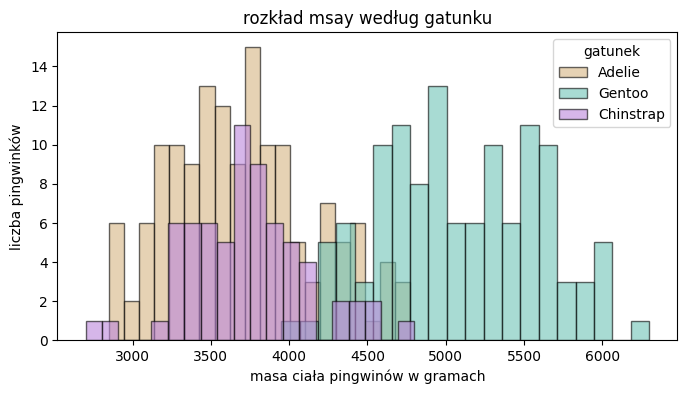

In [18]:
plt.figure(figsize=(8, 4))

for spec, kolor in KOLORY.items():
    dane = ping[ping["species"] == spec]["body_mass_g"]
    plt.hist(
        dane,
        bins=20,
        alpha=0.6,
        color=kolor,
        edgecolor="black",
        label=spec
    )

plt.xlabel("masa ciała pingwinów w gramach")
plt.ylabel("liczba pingwinków")
plt.title("rozkład msay według gatunku")
plt.legend(title="gatunek")

plt.show()

###  Zadanie 4

1. Narysuj histogram **długości dzioba** (`bill_length_mm`) dla całego zbioru.  
   Dodaj linie dla mediany i średniej.

2. Narysuj drugi histogram tej samej cechy, ale z podziałem na gatunki (pętla + `alpha=0.6`).

3. **Pytanie:** Histogram z punktu 1 ma dwa garby. Dlaczego? Co wyjaśnia histogram z punktu 2?

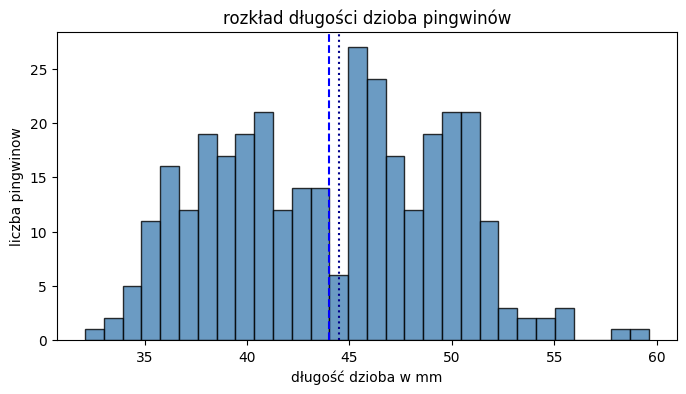

In [19]:
# Twoje rozwiązanie — wykres 1:
plt.figure(figsize=(8, 4))

plt.hist(
    ping["bill_length_mm"],
    bins=30,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
    )

sd = ping["bill_length_mm"].mean().round(2)
md = ping["bill_length_mm"].median()

plt.axvline(x = sd, color="blue", linestyle="--", label=f"srednia = {sd}")
plt.axvline(x = md, color="darkblue", linestyle=":", label=f"mediana = {md}")

plt.xlabel("długość dzioba w mm")
plt.ylabel("liczba pingwinow")
plt.title("rozkład długości dzioba pingwinów")

plt.show()

Text(0.5, 1.0, 'rozkład długości dzioba pingwinów')

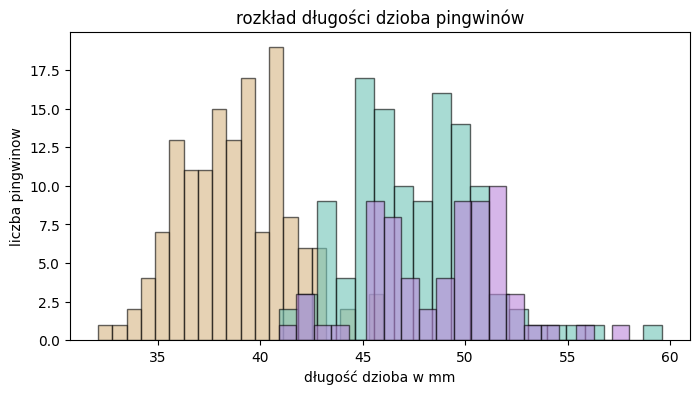

In [20]:
# Twoje rozwiązanie — wykres 2:
plt.figure(figsize=(8, 4))

for spec, kolor in KOLORY.items():
    dane = ping[ping["species"] == spec]["bill_length_mm"]
    plt.hist(
        dane,
        bins=20,
        alpha=0.6,
        color=kolor,
        edgecolor="black",
        label=spec
    )

plt.xlabel("długość dzioba w mm")
plt.ylabel("liczba pingwinow")
plt.title("rozkład długości dzioba pingwinów")

---
## 5. Boxplot i Violinplot — dane odstające i rozkład


### Jak czytać boxplot?

```
         |--wąs--|  [  Q1 | mediana | Q3  ]  |--wąs--|  o (outlier)
```

- **Pudełko** = zakres między Q1 (25%) a Q3 (75%) — tu mieszka środkowe 50% danych
- **Linia środkowa** = mediana
- **Wąsy** = maksymalnie 1.5 × IQR poza pudełkiem
- **Punkty poza wąsami** = potencjalne wartości odstające (outliery)

### 5.1 Podstawowy boxplot

### 5.2 Boxplot z podziałem na płeć

Chcemy zobaczyć czy samce i samice różnią się masą ciała w obrębie każdego gatunku.  
Tu z pomocą przychodzi Seaborn — jedną linią robimy to co w Matplotlib wymagałoby wielu pętli.

### 5.3 Violinplot

Violinplot łączy boxplot z rozkładem gęstości.  
Szerokość "skrzypiec" = gęstość prawdopodobieństwa w danym miejscu — im szerzej, tym więcej obserwacji.

### Zadanie 5

1. Narysuj boxplot dla **długości dzioba** (`bill_length_mm`) — podział wg gatunku.  
   Pokoloruj pudełka kolorami z `KOLORY`.

2. Narysuj violinplot dla **głębokości dzioba** (`bill_depth_mm`) z podziałem na płeć (`hue='sex'`).

3. **Pytanie:** Który gatunek ma największy rozrzut masy ciała (najszersze pudełko)?

In [21]:
# Twoje rozwiązanie — boxplot:




In [22]:
# Twoje rozwiązanie — violinplot:




---
## 6. Scatter plot i adnotacje


Scatter plot pokazuje zależność między dwiema zmiennymi ciągłymi. Każdy punkt = jeden pingwin.

### 6.1 Podstawowy scatter plot

### 6.2 Oznaczenie konkretnego punktu — plt.annotate

`plt.annotate` rysuje strzałkę wskazującą konkretny punkt danych.  
Przydatne gdy chcemy zwrócić uwagę na outlier, rekord, lub konkretnego osobnika.

In [23]:
# Znajdźmy najcięższego pingwina


### Zadanie 6

Na scatter plot `bill_length_mm` vs `bill_depth_mm`:
1. Narysuj wszystkie trzy gatunki różnymi kolorami z `KOLORY`
2. Znajdź pingwina z **najdłuższym dziobem**: `df['bill_length_mm'].idxmax()`
3. Oznacz go strzałką `plt.annotate` z tekstem zawierającym długość dzioba i gatunek

In [24]:
# Twoje rozwiązanie:




---
## 7. Heatmapa korelacji


Korelacja mierzy siłę i kierunek zależności liniowej między dwiema zmiennymi:
- **+1** — pełna korelacja dodatnia (razem rosną)
- **0** — brak korelacji
- **-1** — pełna korelacja ujemna (jedna rośnie, druga maleje)

Macierz korelacji zestawia wszystkie pary zmiennych naraz.

In [25]:
# Wybieramy tylko kolumny liczbowe i liczymy korelacje
cechy    = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
etykiety = ['Dl. dzioba', 'Gl. dzioba', 'Dl. pletwy', 'Masa ciala']



### Zadanie 7

1. Przeczytaj macierz korelacji: która para cech ma **największą korelację dodatnią**?
2. Czy jest para cech z **korelacją ujemną**? Jakie to cechy?
3. **Opcjonalne:** Policz korelacje osobno dla gatunku Gentoo:  
   `corr_gentoo = df[df['species']=='Gentoo'][cechy].corr()`  
   Czy korelacje są inne niż dla całego zbioru?

In [26]:
# Twoje odpowiedzi:
# 1.
# 2.

# Opcjonalne — korelacje dla Gentoo:




---
## 8. Subplots — kilka wykresów obok siebie


`plt.subplots(wiersze, kolumny)` tworzy siatkę wykresów na jednej figurze.  
Zwraca dwa obiekty: `fig` (cała figura) i `axes` (tablica osi).

```python
fig, axes = plt.subplots(1, 2)   # 1 wiersz, 2 kolumny
#  axes[0] — lewy wykres
#  axes[1] — prawy wykres
```

Ważna różnica: zamiast `plt.xlabel()` używamy `axes[i].set_xlabel()`

### 8.1 Trzy histogramy poziomo (1 wiersz, 3 kolumny)

### 8.2 Trzy histogramy pionowo (3 wiersze, 1 kolumna)

Zmieniamy tylko `subplots(3, 1)` i `figsize` — reszta kodu identyczna.

### 8.3 Mieszany układ — wykres słupkowy obok scatter plot

Siatka 1×2 z dwoma różnymi typami wykresów.

###  Zadanie 8

Utwórz siatkę `plt.subplots(2, 2)` z czterema wykresami:
- `axes[0, 0]` — histogram masy ciała (z podziałem na gatunki)
- `axes[0, 1]` — boxplot długości płetwy (wg gatunku, użyj `sns.boxplot(..., ax=axes[0,1])`)
- `axes[1, 0]` — scatter długość dzioba vs głębokość dzioba
- `axes[1, 1]` — heatmapa korelacji (`sns.heatmap(..., ax=axes[1,1])`)

> 💡 Dla siatki 2×2: `axes[wiersz, kolumna]` np. `axes[0, 0]`, `axes[1, 1]`

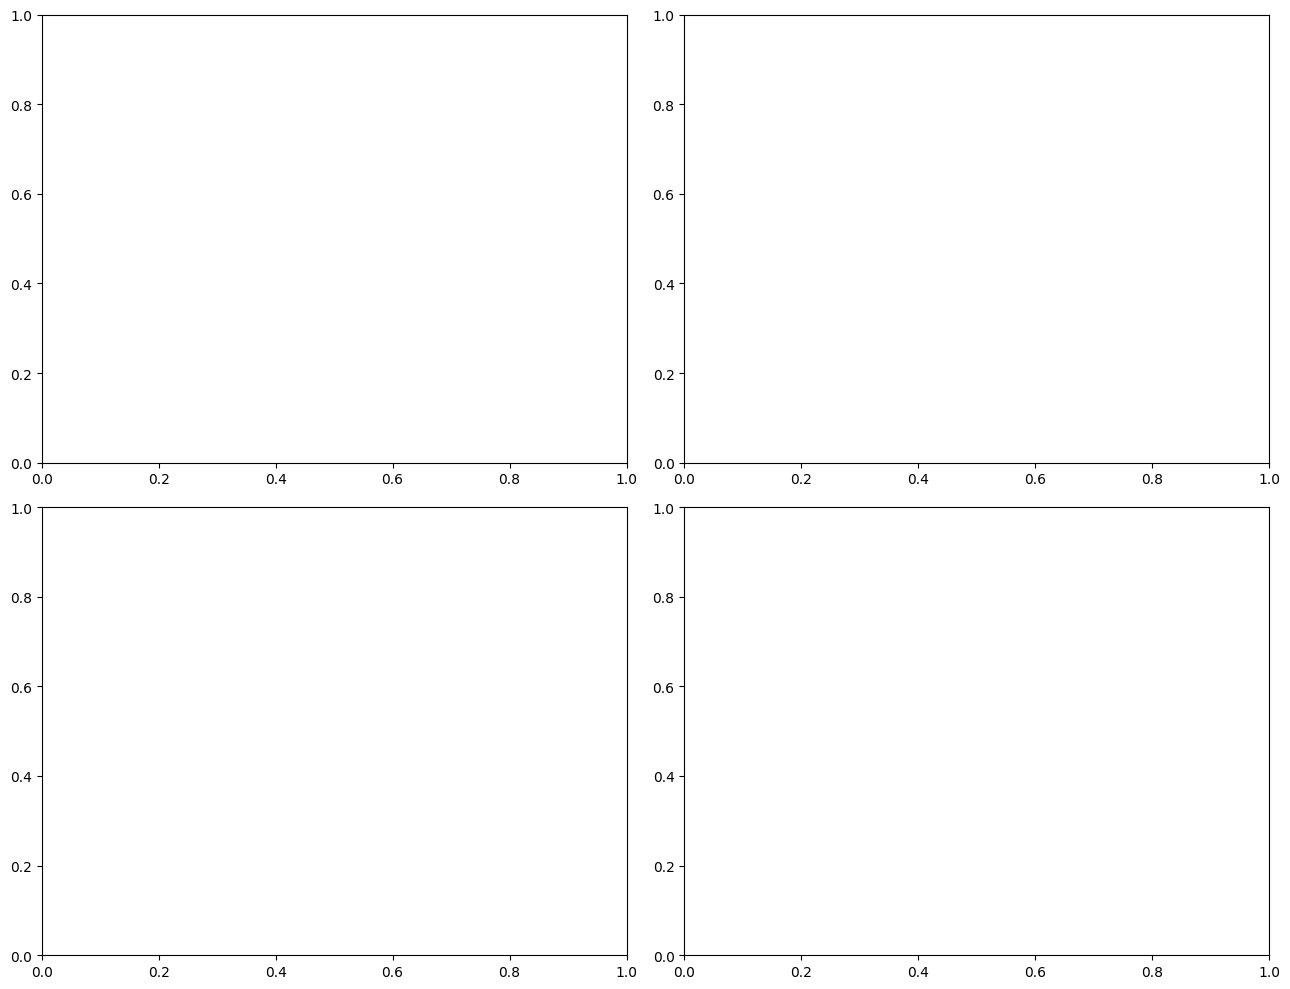

In [27]:
# Twoje rozwiązanie:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# axes[0, 0] — histogram masy ciała


# axes[0, 1] — boxplot dlugosci pletwy
# sns.boxplot(data=df, x='species', y='flipper_length_mm', ..., ax=axes[0, 1])


# axes[1, 0] — scatter ksztaltu dzioba


# axes[1, 1] — heatmapa korelacji
# sns.heatmap(corr, ..., ax=axes[1, 1])


plt.tight_layout()
plt.show()

---
## 9. Seaborn — te same wykresy, mniej kodu


Seaborn to nakładka na Matplotlib. Rozumie ramki danych pandas bezpośrednio  
i obsługuje grupowanie jednym parametrem `hue=`.

**Kluczowa różnica:**
```python
# Matplotlib — pętla, ręczne filtrowanie
for gatunek, kolor in KOLORY.items():
    dane = df[df['species'] == gatunek]['body_mass_g']
    plt.hist(dane, alpha=0.6, color=kolor, label=gatunek)
plt.legend()

# Seaborn — jedna linia robi to samo
sns.histplot(data=df, x='body_mass_g', hue='species')
```

Matplotlib zostaje "pod spodem" — `plt.title()`, `plt.xlabel()`, `plt.savefig()` działają tak samo.

In [28]:
sns.set_theme(style='whitegrid')   # globalny styl — działa na wszystkie kolejne wykresy
print('Seaborn gotowy!')

Seaborn gotowy!


### 9.1 sns.histplot z KDE

### 9.2 sns.boxplot z hue — podział na płeć jednym parametrem

### 9.3 sns.scatterplot i sns.heatmap

### 9.4 sns.pairplot — wszystkie pary naraz

`sns.pairplot` rysuje macierz wykresów: każda cecha vs każda inna cecha.  
Na przekątnej — rozkłady (histogram lub KDE). Poza przekątną — scatter plot.

###  Zadanie 9

1. Narysuj `sns.violinplot` dla `body_mass_g` z podziałem na gatunki i płeć (`hue='sex'`).  
   Porównaj z boxplotem z Zadania 5 — co violinplot mówi więcej?

2. Użyj `sns.pairplot` ale z `diag_kind='hist'` zamiast `'kde'`. Czy coś się zmieniło?

3. Utwórz subplots `1×3` z trzema wykresami Seaborn obok siebie:
   - violinplot długości dzioba
   - boxplot masy ciała
   - scatterplot długość vs głębokość dzioba

In [29]:
# Twoje rozwiązanie — zadanie 1:




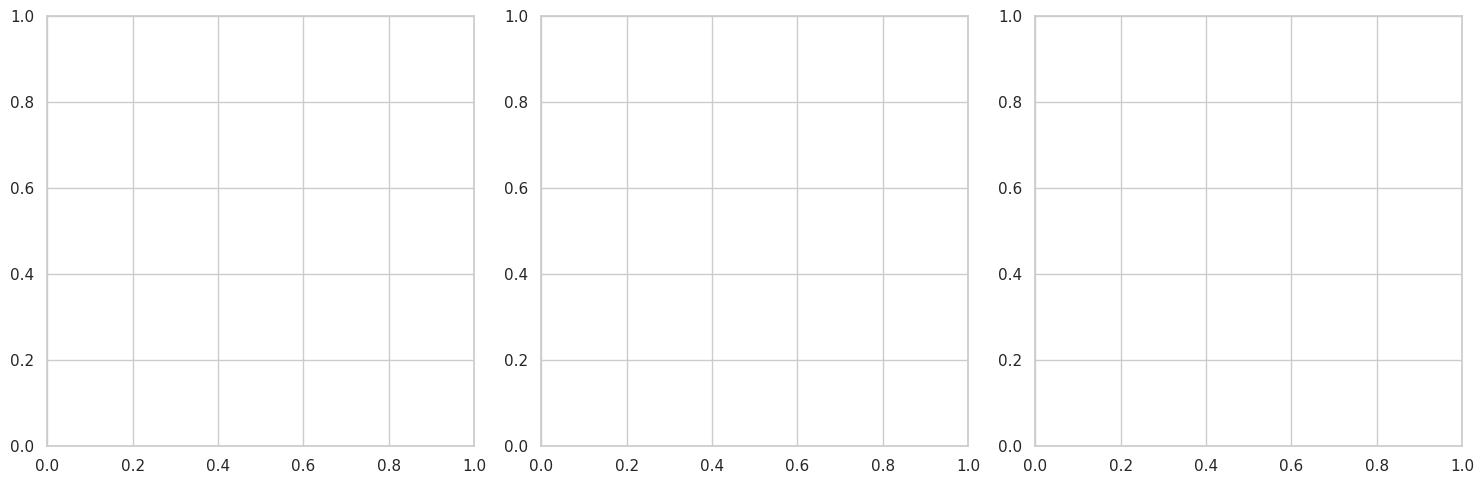

In [30]:
# Twoje rozwiązanie — zadanie 3:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0] — violinplot


# axes[1] — boxplot


# axes[2] — scatterplot


plt.tight_layout()
plt.show()

---
## Podsumowanie

### Matplotlib — kiedy używać?
- Pełna kontrola nad każdym elementem wykresu
- Własne pętle, niestandardowe układy
- `plt.annotate` — wskazywanie konkretnych punktów

### Seaborn — kiedy używać?
- Szybka eksploracja danych z grupowaniem (`hue=`)
- `pairplot` — bez odpowiednika w Matplotlib

### Mapa funkcji

| Zadanie | Matplotlib | Seaborn |
|---------|------------|---------|
| Linia | `plt.plot()` | — |
| Punkty | `plt.scatter()` | `sns.scatterplot()` |
| Histogram | `plt.hist()` | `sns.histplot()` |
| Boxplot | `plt.boxplot()` | `sns.boxplot()` |
| Violinplot | — | `sns.violinplot()` |
| Heatmapa | `plt.imshow()` | `sns.heatmap()` |
| Linia pionowa | `plt.axvline()` | — |
| Wiele wykresów | `plt.subplots()` | `ax=` w sns |
| Wszystkie pary | — | `sns.pairplot()` |
| Grupowanie danych | ręczna pętla | `hue='kolumna'` |

### Cechy dobrego wykresu
- Tytuł, etykiety obu osi **z jednostkami**, legenda
- `alpha` gdy dane się nakładają
- `plt.tight_layout()` zapobiega nakładaniu etykiet
- Spójna paleta kolorów przez cały projekt